In [20]:
import os 
import mne 
from mne.preprocessing import ICA, corrmap, create_ecg_epochs , create_eog_epochs

In [21]:
sample_data_raw_file = '/mnt/disk1/aiotlab/hieupc/CBraMod/EEG2100/edf_files/FA5550A0_1-1+.edf'
raw = mne.io.read_raw_edf(sample_data_raw_file,  preload=True)
raw.crop(tmax = 60).pick(picks = ['eeg'])

Extracting EDF parameters from /mnt/disk1/aiotlab/hieupc/CBraMod/EEG2100/edf_files/FA5550A0_1-1+.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 51499  =      0.000 ...   102.998 secs...


<RawEDF | FA5550A0_1-1+.edf, 44 x 30001 (60.0 s), ~10.1 MiB, data loaded>

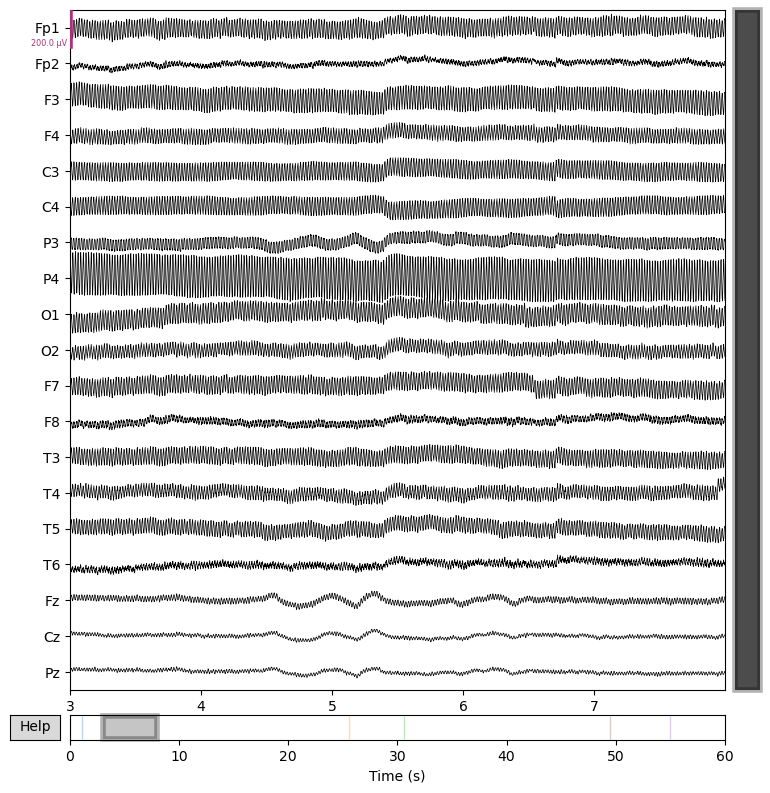

In [22]:
# pick some channels that clearly show heartbeats and blinks
# regexp = r"(MEG [12][45][123]1|EEG 00.)"
# eeg_channels = [ch for ch in raw.ch_names if any(eeg_name in ch.upper() for eeg_name in ['FP1']) and ch not in ['SpO2', 'EtCO2', 'Pulse', 'CO2Wave', 'DC03', 'DC04', 'DC05', 'DC06']]
eeg_channels = [ch for ch in raw.ch_names if any(eeg_name in ch.upper() for eeg_name in ['FP1', 'FP2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'FZ', 'CZ', 'PZ']) and ch not in ['SpO2', 'EtCO2', 'Pulse', 'CO2Wave', 'DC03', 'DC04', 'DC05', 'DC06']]
# eeg_channels = raw.ch_names
# artifact_picks = mne.pick_channels_regexp(raw.ch_names, regexp=regexp)
raw_eeg = raw.copy().pick(eeg_channels)
if eeg_channels:
    raw_eeg.plot(
    scalings=dict(eeg=100e-6),  # scale in Volts (50 µV here)
    duration=5,              # time window in seconds
    start= 3                   # optional: start time in seconds
    )

In [23]:
filt_raw = raw.copy().filter(l_freq = 0.5 , h_freq = None)

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 0.5 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Filter length: 3301 samples (6.602 s)



In [24]:
ica = ICA(n_components= 10, max_iter= 'auto' , random_state= 42)
ica.fit(filt_raw , picks = ['eeg'])
ica

Fitting ICA to data using 44 channels (please be patient, this may take a while)
Selecting by number: 10 components
Fitting ICA took 3.3s.


/mnt/disk1/aiotlab/envs/hieupcvp/lib/python3.12/site-packages/sklearn/decomposition/_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(
/tmp/ipykernel_1213194/3320275107.py:2: RuntimeWarning: Using n_components=10 (resulting in n_components_=10) may lead to an unstable mixing matrix estimation because the ratio between the largest (35) and smallest (7.7e-07) variances is too large (> 1e6); consider setting n_components=0.999999 or an integer <= 6
  ica.fit(filt_raw , picks = ['eeg'])


Method,fastica
Fit parameters,algorithm=parallelfun=logcoshfun_args=Nonemax_iter=1000
Fit,1000 iterations on raw data (30001 samples)
ICA components,10
Available PCA components,44
Channel types,eeg
ICA components marked for exclusion,—


In [25]:
explained_var_ratio = ica.get_explained_variance_ratio(filt_raw)
for channel_type, ratio in explained_var_ratio.items():
    print(f"Fraction of {channel_type} variance explained by all components: {ratio}")

Fraction of eeg variance explained by all components: 0.9999999495469486


In [26]:
explained_var_ratio = ica.get_explained_variance_ratio(
    filt_raw, components=[0], ch_type="eeg"
)
# This time, print as percentage.
ratio_percent = round(100 * explained_var_ratio["eeg"])
print(
    f"Fraction of variance in EEG signal explained by first component: {ratio_percent}%"
)

Fraction of variance in EEG signal explained by first component: 73%


Creating RawArray with float64 data, n_channels=10, n_times=30001
    Range : 0 ... 30000 =      0.000 ...    60.000 secs
Ready.


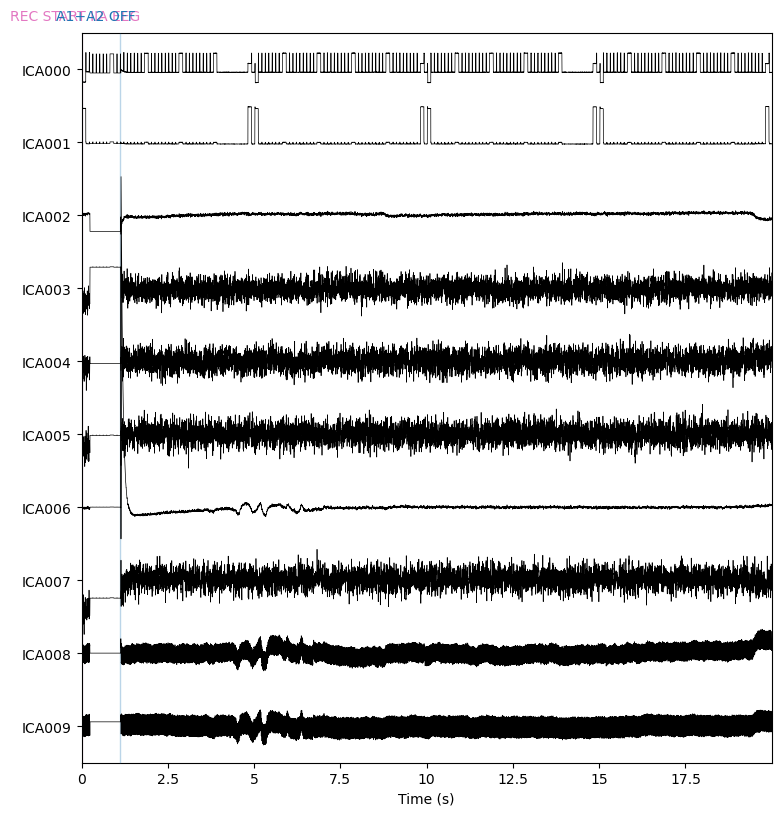

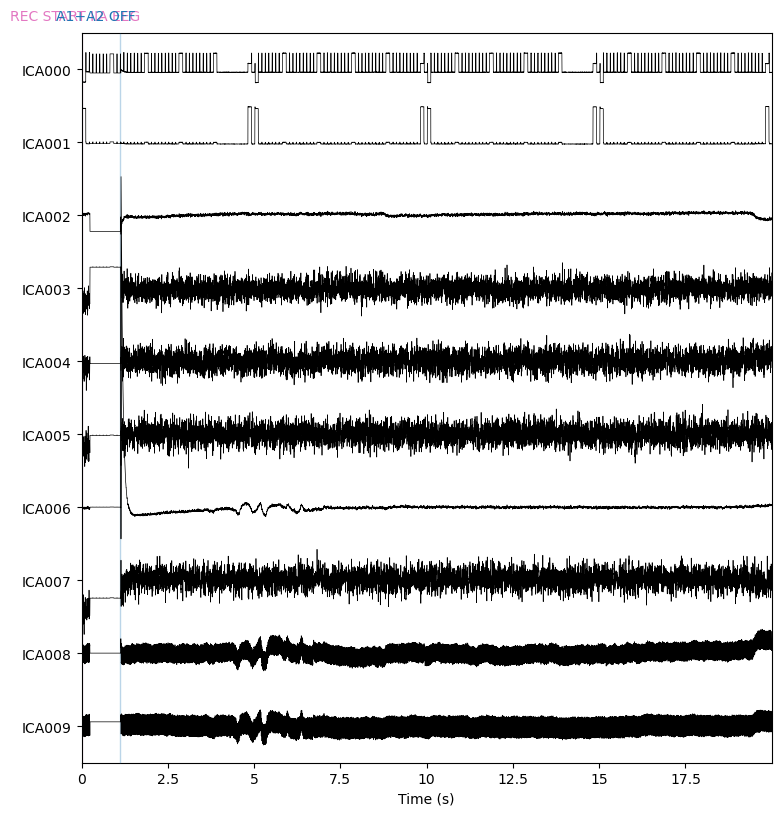

In [27]:
raw.load_data()
ica.plot_sources(raw, show_scrollbars=False)

In [28]:

# barplot of ICA component "ECG match" scores
# ica.plot_scores(ecg_scores)

# plot diagnostics
# ica.plot_properties(raw, picks=ecg_indices)

# plot ICs applied to raw data, with ECG matches highlighted
# ica.plot_sources(raw, show_scrollbars=False)

# plot ICs applied to the averaged ECG epochs, with ECG matches highlighted
# ica.plot_sources(ecg_evoked)

In [29]:
# refit the ICA with 30 components this time
new_ica = ICA(n_components=30, max_iter="auto", random_state=42)
new_ica.fit(filt_raw)

eog_indices, eog_scores = new_ica.find_bads_eog(
    raw, ch_name='Fp1', threshold=0.9
)

ecg_indices, ecg_scores = new_ica.find_bads_ecg(
    raw, ch_name='C3', method='correlation', threshold=0.9
)

# find which ICs match the ECG pattern
# ecg_indices, ecg_scores = new_ica.find_bads_ecg(
#     raw, method="correlation", threshold="auto"
# )
new_ica.exclude = ecg_indices + eog_indices
reconst_raw = raw.copy()
new_ica.apply(reconst_raw)

Fitting ICA to data using 44 channels (please be patient, this may take a while)
Selecting by number: 30 components
Fitting ICA took 0.4s.
Using EOG channel: Fp1
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5000 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:


/tmp/ipykernel_1213194/1771499972.py:3: RuntimeWarning: Using n_components=30 (resulting in n_components_=30) may lead to an unstable mixing matrix estimation because the ratio between the largest (35) and smallest (1.3e-08) variances is too large (> 1e6); consider setting n_components=0.999999 or an integer <= 6
  new_ica.fit(filt_raw)


- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5000 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 8 - 16 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 8.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 7.75 Hz)
- Upper passband edge: 16.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 16.25 Hz)
- Filter length: 5000 samples (10.000 s)

... filtering target
Setting up band-pass filter from 8 - 16 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal 

<RawEDF | FA5550A0_1-1+.edf, 44 x 30001 (60.0 s), ~10.1 MiB, data loaded>

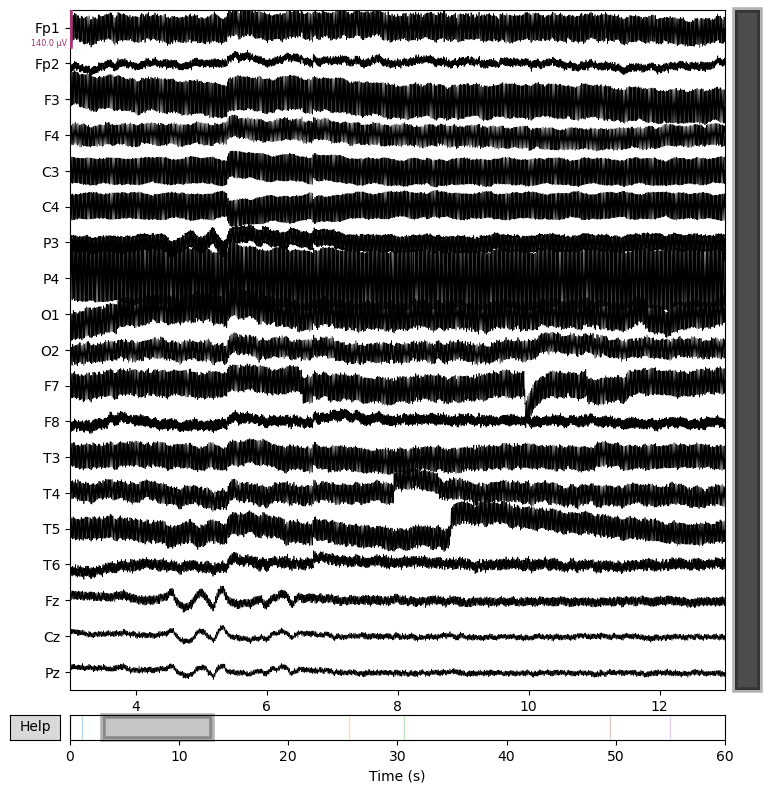

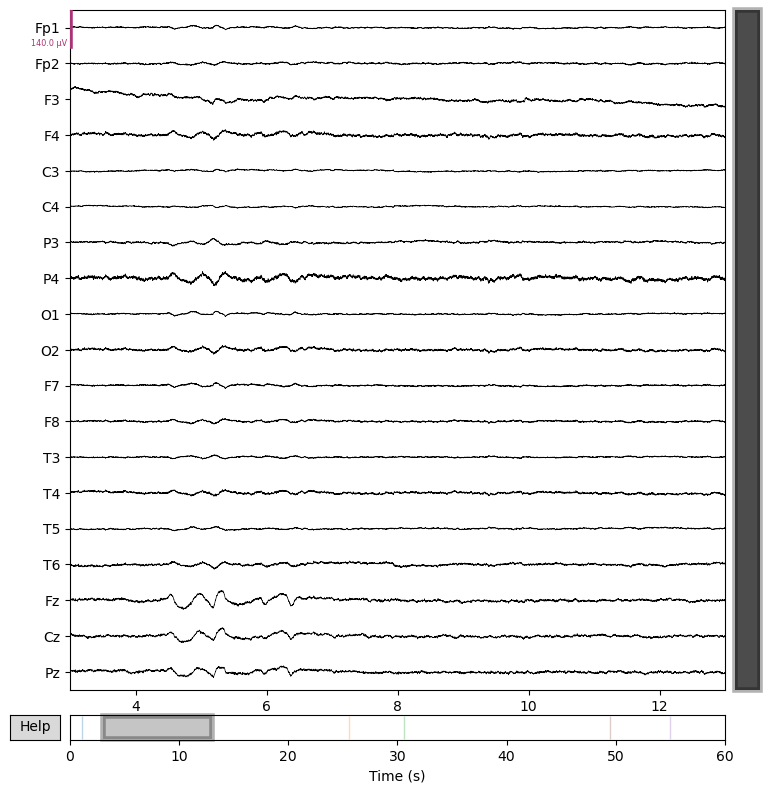

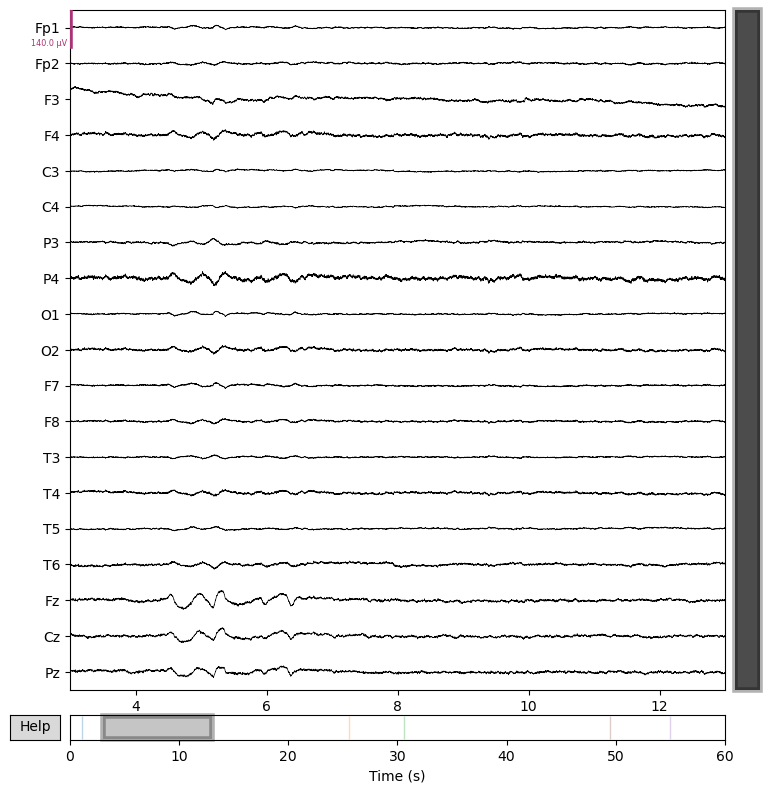

In [30]:
# ica.apply() changes the Raw object in-place, so let's make a copy first:


raw.pick(eeg_channels).plot(
    scalings=dict(eeg=70e-6),  # scale in Volts (50 µV here)
    duration=10,              # time window in seconds
    start= 3  
)
reconst_raw.pick(eeg_channels).plot(
    scalings=dict(eeg=70e-6),  # scale in Volts (50 µV here)
    duration=10,              # time window in seconds
    start= 3  
)

# del reconst_raw

In [31]:
import numpy as np

In [32]:

def read_edf_cut_duration(raw):
    try:
        # raw = mne.io.read_raw_edf(file_path , preload= True)
        eeg_channels = [ch for ch in raw.ch_names if any(eeg_name in ch.upper() for eeg_name in ['FP1', 'FP2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'FZ', 'CZ', 'PZ']) and ch not in ['SpO2', 'EtCO2', 'Pulse', 'CO2Wave', 'DC03', 'DC04', 'DC05', 'DC06']]
        raw.pick(eeg_channels)
        data , times = raw.get_data(return_times = True)
        sfreq = int(raw.info['sfreq'])

        segment_len = int(sfreq*0.2)
        n_segments = data.shape[1]//segment_len

        valid_segments = []
        for i in range(n_segments):
            start = i*segment_len
            end = start + segment_len 
            seg = data[: , start:end]
            seg_uV = seg*1e6 

            if np.max(np.abs(seg_uV)) <= 100:
                valid_segments.append(seg)

        if valid_segments:
            filtered_data = np.concatenate(valid_segments , axis = 1)
        else:
            raise ValueError("No valid segment found, all segment have range > 100 muyV")

        info = raw.info.copy()

        raw_filtered = mne.io.RawArray(filtered_data, info)
        duration_seconds = filtered_data.shape[1]/sfreq
        print(f"Time left : {duration_seconds} secs , Original duration :{raw.times[-1]}")
        return duration_seconds
    except Exception as e:
        return 0 , False, str(e)


In [33]:
# raw.pick(eeg_channels)
# data , times = raw.get_data(return_times = True)
# sfreq = int(raw.info['sfreq'])

# segment_len = int(sfreq*0.2)
# n_segments = data.shape[1]//segment_len

# valid_segments = []
# for i in range(n_segments):
#     start = i*segment_len
#     end = start + segment_len 
#     seg = data[: , start:end]
#     seg_uV = seg*1e6 

#     if np.max(np.abs(seg_uV)) <= 100:
#         valid_segments.append(seg)

# if valid_segments:
#     filtered_data = np.concatenate(valid_segments , axis = 1)
# else:
#     raise ValueError("No valid segment found, all segment have range > 100 muyV")

# info = raw.info.copy()

# raw_filtered = mne.io.RawArray(filtered_data, info)
# duration_seconds = filtered_data.shape[1]/sfreq
# print(f"Time left : {duration_seconds} secs , Original duration :{raw.times[-1]}")

In [34]:
read_edf_cut_duration(raw)
read_edf_cut_duration(reconst_raw)

Creating RawArray with float64 data, n_channels=19, n_times=300
    Range : 0 ... 299 =      0.000 ...     0.598 secs
Ready.
Time left : 0.6 secs , Original duration :60.0
Creating RawArray with float64 data, n_channels=19, n_times=24300
    Range : 0 ... 24299 =      0.000 ...    48.598 secs
Ready.
Time left : 48.6 secs , Original duration :60.0


48.6

In [35]:
EDF_FOLDER = "/mnt/disk1/aiotlab/hieupc/CBraMod/EEG2100/edf_files"

EEG_INCLUDE = ['FP1', 'FP2', 'F3', 'F4', 'C3', 'C4',
               'P3', 'P4', 'O1', 'O2', 'F7', 'F8',
               'T3', 'T4', 'T5', 'T6', 'FZ', 'CZ', 'PZ']
EEG_EXCLUDE = ['SPO2', 'ETCO2', 'PULSE', 'CO2WAVE',
               'DC03', 'DC04', 'DC05', 'DC06']


In [38]:

def ICA_for_file(file_path):
    # Đọc toàn bộ dữ liệu
    raw_full = mne.io.read_raw_edf(file_path, preload=True)

    # Lọc kênh EEG hợp lệ
    eeg_channels = [
        ch for ch in raw_full.ch_names
        if any(eeg_name in ch.upper() for eeg_name in EEG_INCLUDE)
        and ch.upper() not in EEG_EXCLUDE
    ]
    raw_full.pick(eeg_channels)

    # Tạo bản copy để fit ICA trên 60s đầu
    raw_for_ica = raw_full.copy()
    duration = raw_for_ica.times[-1]
    tmax = min(duration, 60)  # chỉ lấy tối đa 60s
    raw_for_ica.crop(tmax=tmax)

    # Lọc tín hiệu (high-pass 0.5 Hz để loại bỏ drift)
    filt_raw = raw_for_ica.filter(l_freq=0.5, h_freq=None)

    # Fit ICA
    ica = ICA(n_components=10, max_iter="auto", random_state=42)
    ica.fit(filt_raw)

    # Tìm EOG artifact
    eog_indices, _ = ica.find_bads_eog(raw_for_ica, ch_name='Fp1', threshold=0.9)

    # Tìm ECG artifact
    ecg_indices, _ = ica.find_bads_ecg(raw_for_ica, ch_name='C3', method='correlation', threshold=0.9)

    # Loại bỏ artifact
    ica.exclude = ecg_indices + eog_indices

    # Áp dụng ICA lên toàn bộ dữ liệu
    reconst_raw = raw_full.copy()
    ica.apply(reconst_raw)

    return reconst_raw



def read_edf_cut_duration(raw):
    eeg_channels = [
        ch for ch in raw.ch_names
        if any(eeg_name in ch.upper() for eeg_name in EEG_INCLUDE)
        and ch.upper() not in EEG_EXCLUDE
    ]
    raw.pick(eeg_channels)

    data, times = raw.get_data(return_times=True)
    sfreq = int(raw.info['sfreq'])

    segment_len = int(sfreq * 0.1)
    n_segments = data.shape[1] // segment_len

    valid_segments = []
    for i in range(n_segments):
        start = i * segment_len
        end = start + segment_len
        seg = data[:, start:end]
        seg_uV = seg * 1e6  # V -> µV

        if np.max(np.abs(seg_uV)) <= 100:
            valid_segments.append(seg)

    if valid_segments:
        filtered_data = np.concatenate(valid_segments, axis=1)
    else:
        raise ValueError("No valid segment found, all segments > 100 µV")

    info = raw.info.copy()
    raw_filtered = mne.io.RawArray(filtered_data, info)
    duration_seconds = filtered_data.shape[1] / sfreq

    return duration_seconds


In [39]:
file = '/mnt/disk1/aiotlab/hieupc/CBraMod/EEG2100/edf_files/FA5550A0_1-1+.edf'

reconst_raw = ICA_for_file(file)
print(read_edf_cut_duration(reconst_raw))

Extracting EDF parameters from /mnt/disk1/aiotlab/hieupc/CBraMod/EEG2100/edf_files/FA5550A0_1-1+.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 51499  =      0.000 ...   102.998 secs...
Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 0.5 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Filter length: 3301 samples (6.602 s)

Fitting ICA to data using 19 channels (please be patient, this may take a while)
Selecting by number: 10 components
Fitting ICA took 0.1s.
Using EOG channel: Fp1
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward a